In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pyodbc

In [3]:
# Create SQL Server connection
connection = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DILLIBABU\\SQLEXPRESS;'
    'DATABASE=CFB;'
    'Trusted_Connection=yes;'
)

# Load data from database table
query = "SELECT * FROM riser"
df = pd.read_sql(query, connection)

C:\Users\dilli\AppData\Local\Temp\ipykernel_15036\2854011698.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [4]:
# Select input features and target variable
X = df[['Ug', 'Gs', 'z', 'r/R', 'Particle_velocity', 'Solid_flux']]
y = df['Solid_holdup']

In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Standardize features for better DL performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

# Define input layer properly
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Output layer
model.add(Dense(1))

In [9]:
# Compile model with optimizer and loss function
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [10]:
# Train the neural network
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0147 - mae: 0.0867 - val_loss: 0.0054 - val_mae: 0.0573
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0474 - val_loss: 0.0036 - val_mae: 0.0426
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - mae: 0.0414 - val_loss: 0.0035 - val_mae: 0.0423
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - mae: 0.0377 - val_loss: 0.0034 - val_mae: 0.0407
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - mae: 0.0349 - val_loss: 0.0029 - val_mae: 0.0365
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - mae: 0.0317 - val_loss: 0.0029 - val_mae: 0.0371
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - mae: 0.0304 - val_loss: 0.0033 - val_mae: 0.0380
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mae: 0.0288 - val_loss: 0.0029 - val_mae: 0.0343
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.00

In [11]:
# Make predictions on test data
y_pred = model.predict(X_test).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


In [12]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.02344487409697225
MSE: 0.0014874452538084523
RMSE: 0.03856741181111914
R2 Score: 0.9234420063243101


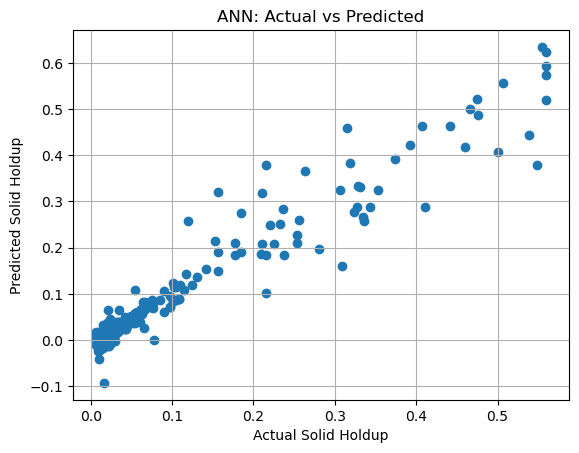

In [13]:
# Plot Actual vs Predicted values
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Solid Holdup")
plt.ylabel("Predicted Solid Holdup")
plt.title("ANN: Actual vs Predicted")
plt.grid()
plt.show()

In [23]:
# Save trained model in modern Keras format
model.save("solid_holdup_ann_model.keras")

In [24]:
import tensorflow as tf

# Load saved model
loaded_model = tf.keras.models.load_model("solid_holdup_ann_model.keras", compile=False)

In [25]:
loaded_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [26]:
# New input data with feature names
new_data = pd.DataFrame([{
    'Ug': 5,
    'Gs': 100,
    'z': 3,
    'r/R': 0.5,
    'Particle_velocity': 2.5,
    'Solid_flux': 250
}])

# Apply same scaler used during training
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = loaded_model.predict(new_data_scaled)

print("Predicted Solid Holdup:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted Solid Holdup: 0.01455111
